

# REQUIRED LIBRARY



In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)



# LOAD DATASET



In [2]:
df = pd.read_csv('cybersecurity_intrusion_data.csv', encoding = 'latin1')
df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 1010.7 KB


In [4]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [5]:
df.head(10)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,SID_00006,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,SID_00007,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,SID_00008,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,SID_00009,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,SID_00010,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


In [6]:
df.tail(10)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
9527,SID_09528,588,TCP,5,158.789714,AES,0.728379,0,Firefox,1,1
9528,SID_09529,535,TCP,7,50.518476,DES,0.767659,1,Edge,1,1
9529,SID_09530,469,TCP,1,2487.078455,NaN,0.497153,0,Chrome,0,0
9530,SID_09531,661,UDP,5,1037.597568,NaN,0.613622,3,Chrome,0,1
9531,SID_09532,746,TCP,7,315.151758,DES,0.190059,3,Chrome,0,1
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,NaN,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0
9536,SID_09537,340,TCP,6,86.876744,NaN,0.277069,4,Chrome,1,1


In [7]:
df.isnull().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64



# CLEANING NULL VALUE FROM DATASET



In [8]:
missing_values= df.isnull().sum()

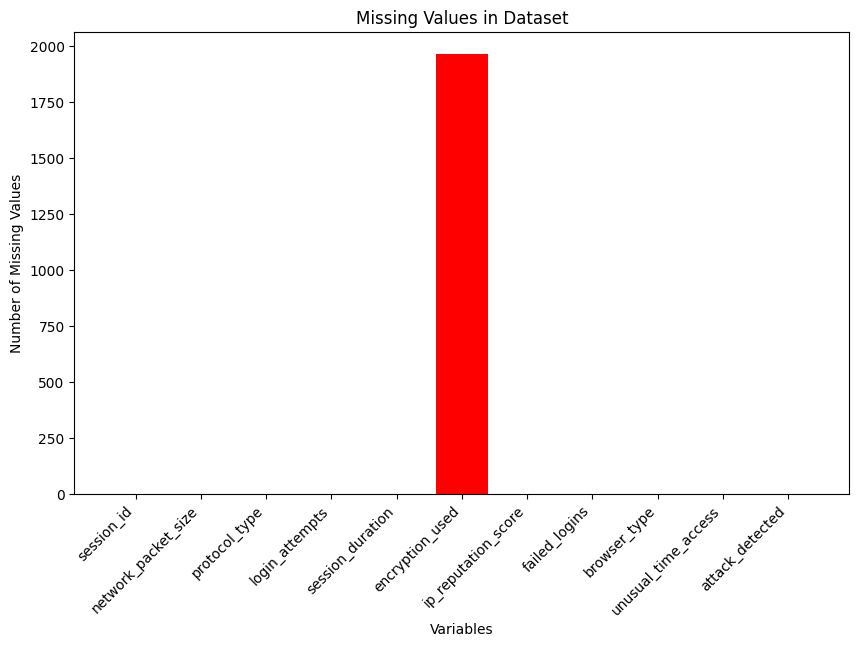

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(missing_values.index, missing_values.values, color='red')
plt.xlabel('Variables')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values in Dataset')
plt.xticks(rotation=45, ha='right') 
plt.show()

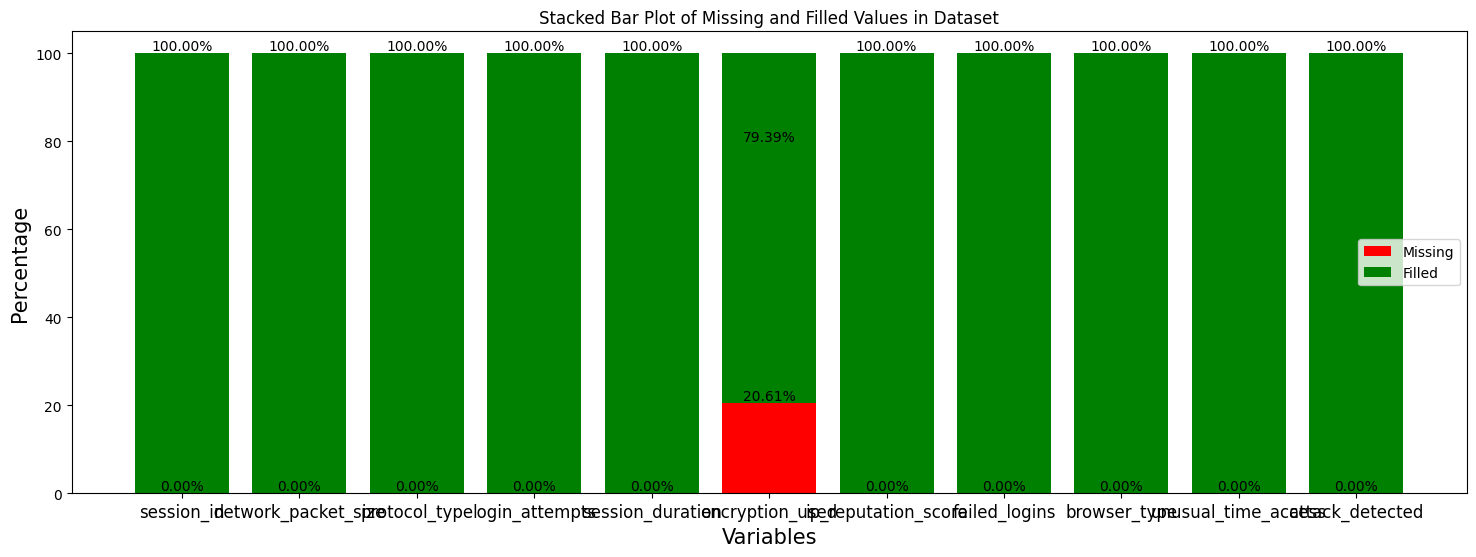

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
filled_percentage = 100 - missing_percentage


plt.figure(figsize=(18, 6))

bars1= plt.bar(missing_percentage.index, missing_percentage, label='Missing', color='red')
bars2= plt.bar(filled_percentage.index, filled_percentage, bottom=missing_percentage, label='Filled', color='green')

plt.xlabel('Variables',fontsize=15)
plt.ylabel('Percentage',fontsize=15)
plt.title('Stacked Bar Plot of Missing and Filled Values in Dataset')
plt.xticks(fontsize=12)
plt.legend()

for bar1, bar2 in zip(bars1, bars2):
    yval = bar1.get_height()
    plt.text(bar1.get_x() + bar1.get_width() / 2, yval, f'{yval:.2f}%', ha='center', va='bottom')
# 
for bar1, bar2 in zip(bars1, bars2):
    yval = bar2.get_height()
    plt.text(bar2.get_x() + bar2.get_width() / 2, yval, f'{yval:.2f}%', ha='center', va='bottom')

plt.show()

In [11]:
df.isnull().sum()

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

### ENCRYPTION_USED

In [12]:
df['encryption_used'].unique()

<ArrowStringArray>
['DES', 'AES', nan]
Length: 3, dtype: str

In [13]:
# Find the most frequent encryption method (the mode)
most_frequent = df['encryption_used'].mode()[0]  # This will be 'AES'

# Fill missing values with the mode
df['encryption_used'] = df['encryption_used'].fillna(most_frequent)

# Verify the changes
print(df['encryption_used'].value_counts())

encryption_used
AES    6672
DES    2865
Name: count, dtype: int64


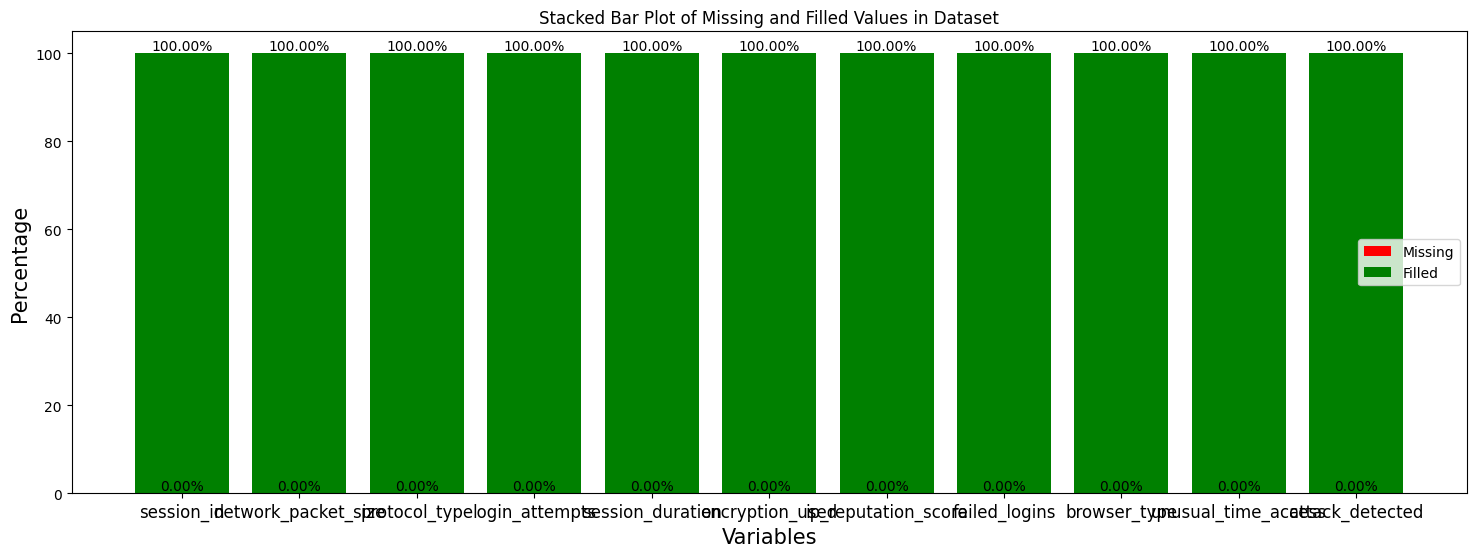

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
filled_percentage = 100 - missing_percentage


plt.figure(figsize=(18, 6))

bars1= plt.bar(missing_percentage.index, missing_percentage, label='Missing', color='red')
bars2= plt.bar(filled_percentage.index, filled_percentage, bottom=missing_percentage, label='Filled', color='green')

plt.xlabel('Variables',fontsize=15)
plt.ylabel('Percentage',fontsize=15)
plt.title('Stacked Bar Plot of Missing and Filled Values in Dataset')
plt.xticks(fontsize=12)
plt.legend()

for bar1, bar2 in zip(bars1, bars2):
    yval = bar1.get_height()
    plt.text(bar1.get_x() + bar1.get_width() / 2, yval, f'{yval:.2f}%', ha='center', va='bottom')
# 
for bar1, bar2 in zip(bars1, bars2):
    yval = bar2.get_height()
    plt.text(bar2.get_x() + bar2.get_width() / 2, yval, f'{yval:.2f}%', ha='center', va='bottom')

plt.show()

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 1015.3 KB


In [16]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000




# <b>ADDING EXTRA COLUMNS FOR BETTER INSIGHTS



### FAILED_LOGIN_RATIO

In [17]:
df['failed_login_ratio'] = df['failed_logins'] / (df['login_attempts'] + 1e-5)


### TRAFFIC_DENSITY

In [18]:
df['traffic_density'] = df['network_packet_size'] / (df['session_duration'] + 1e-5)

### RISK_SCORE_INDEX

In [19]:
df['risk_score_index'] = df['unusual_time_access'] * (1.0 - df['ip_reputation_score'])

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
 11  failed_login_ratio   9537 non-null   float64
 12  traffic_density      9537 non-null   float64
 13  risk_score_index     9537 non-null   float64
dtypes: float64(5), int64(5), str(4)
memory usage: 1.2 MB


In [21]:
df.isnull().sum()

session_id             0
network_packet_size    0
protocol_type          0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
failed_login_ratio     0
traffic_density        0
risk_score_index       0
dtype: int64



# OUTLIERS DETECTION AND REMOVE OUTLIERS 



In [22]:
df.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,failed_login_ratio,traffic_density,risk_score_index
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101,0.519609,4.865991,0.100460
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220,0.564493,40.514124,0.248644
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000,0.000000,0.009290,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000,0.200000,0.396914,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000,0.333333,0.846389,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000,0.666664,2.088565,0.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000,4.999950,1553.968921,0.995973


# network_packet_size

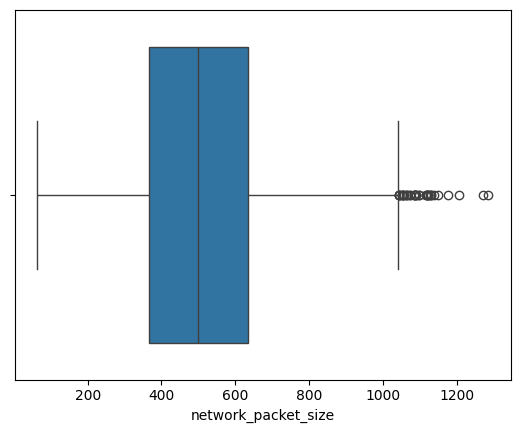

In [23]:
sns.boxplot(data=df,x='network_packet_size')
plt.show()

In [24]:
x = np.quantile(df['network_packet_size'], (0.25, 0.75))

Q3 = x[1]
Q1 = x[0]
print('Q1: ', Q1)
print('Q3: ', Q3)

Q1:  365.0
Q3:  635.0


In [25]:
IQR = Q3 - Q1

uw = Q3 + 1.5*IQR
lw = Q1 - 1.5*IQR

print('Upper Bound: ', uw)
print('Lower Bound: ', lw)

Upper Bound:  1040.0
Lower Bound:  -40.0


In [26]:
df['network_packet_size'] = np.where(df['network_packet_size'] > uw, uw, df['network_packet_size'])
df['network_packet_size'] = np.where(df['network_packet_size'] < lw, lw, df['network_packet_size'])

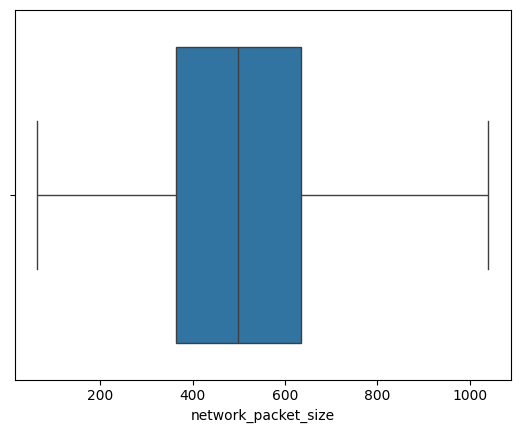

In [27]:
sns.boxplot(data=df,x='network_packet_size')
plt.show()

# session_duration

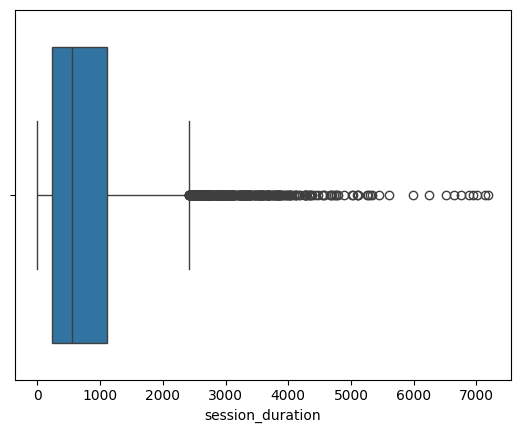

In [28]:
sns.boxplot(data=df,x='session_duration')
plt.show()

In [29]:
x = np.quantile(df['session_duration'], (0.25, 0.75))

Q3 = x[1]
Q1 = x[0]
print('Q1: ', Q1)
print('Q3: ', Q3)

Q1:  231.95300642419463
Q3:  1105.3806022240433


In [30]:
IQR = Q3 - Q1

uw = Q3 + 1.5*IQR
lw = Q1 - 1.5*IQR

print('Upper Bound: ', uw)
print('Lower Bound: ', lw)

Upper Bound:  2415.521995923816
Lower Bound:  -1078.1883872755782


In [31]:
df['session_duration'] = np.where(df['session_duration'] > uw, uw, df['session_duration'])
df['session_duration'] = np.where(df['session_duration'] < lw, lw, df['session_duration'])

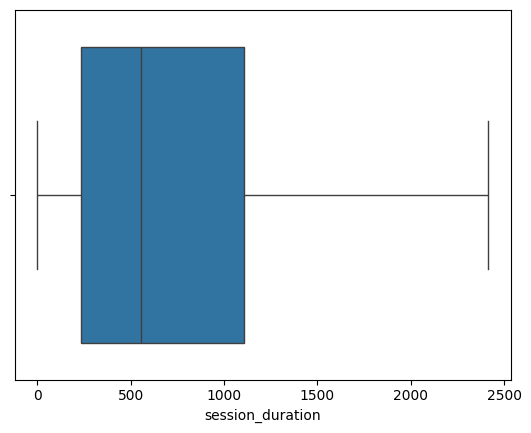

In [32]:
sns.boxplot(data=df,x='session_duration')
plt.show()



# EDA 



In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   float64
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
 11  failed_login_ratio   9537 non-null   float64
 12  traffic_density      9537 non-null   float64
 13  risk_score_index     9537 non-null   float64
dtypes: float64(6), int64(4), str(4)
memory usage: 1.2 MB


# network_packet_size VS protocol_type

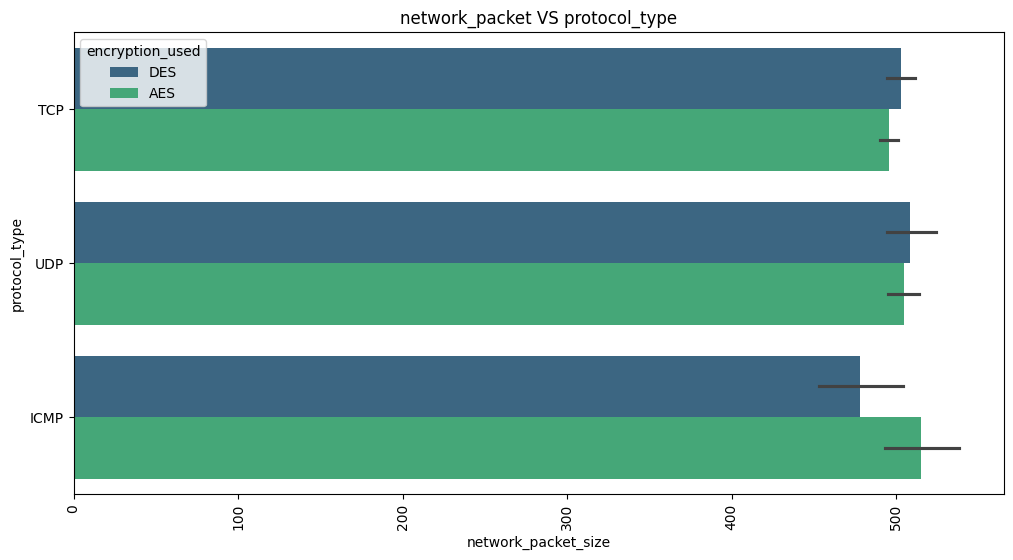

In [34]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x='network_packet_size', y='protocol_type',hue='encryption_used', palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('network_packet_size')
plt.ylabel('protocol_type')
plt.title('network_packet VS protocol_type')
plt.show()

# session_duration

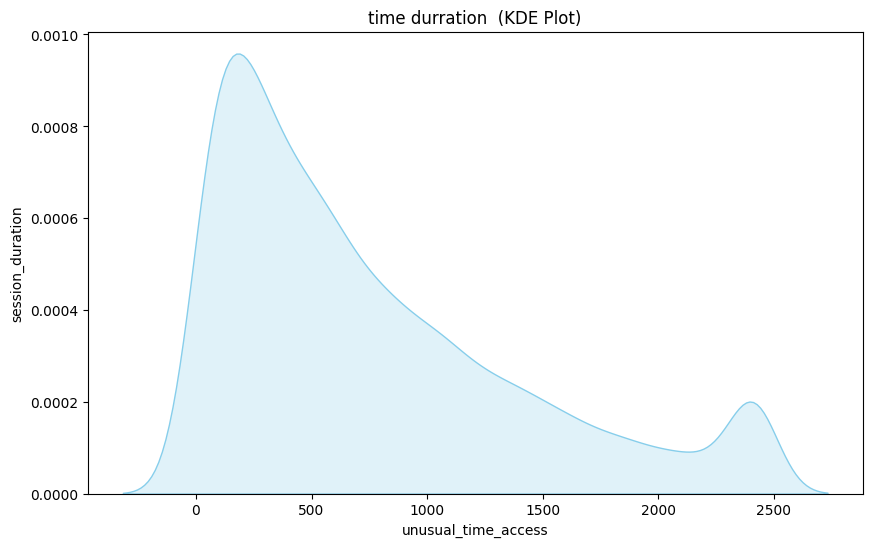

In [35]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['session_duration'], color='skyblue', fill=True)
plt.xlabel('unusual_time_access')
plt.ylabel('session_duration')
plt.title('time durration  (KDE Plot)')
plt.show()

# login_attempts

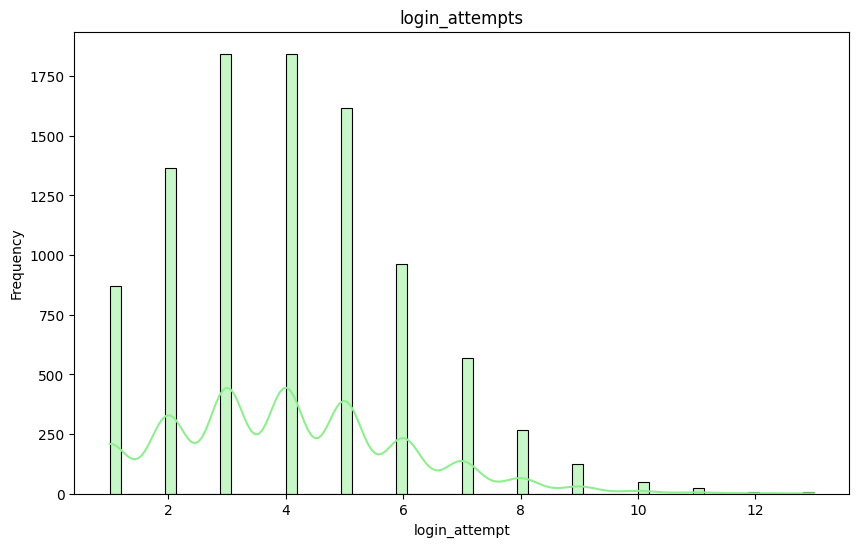

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(df['login_attempts'], kde=True, color='lightgreen')
plt.xlabel('login_attempt')
plt.ylabel('Frequency')
plt.title('login_attempts')
plt.show()

# session_duration VS ip_reputation_score

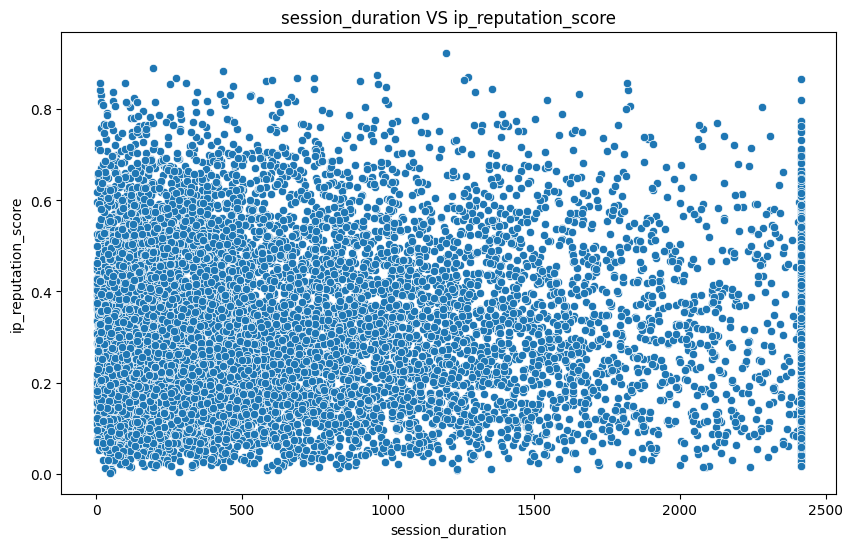

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='session_duration', y='ip_reputation_score')
plt.title('session_duration VS ip_reputation_score')
plt.xlabel('session_duration')
plt.ylabel('ip_reputation_score')
plt.show()

# Distribution of Protocol Types

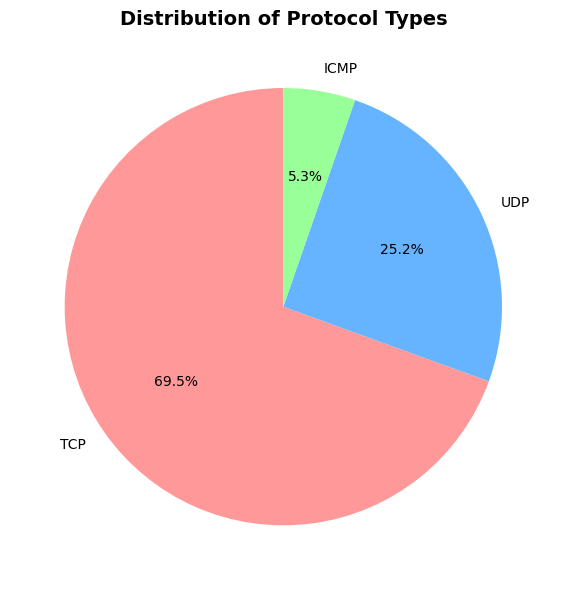

In [38]:
protocol_counts = df['protocol_type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
protocol_counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff', '#99ff99'], 
    ax=ax
)
ax.set_ylabel('')
ax.set_title('Distribution of Protocol Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# multi analysis

In [39]:
numeric_columns=df.select_dtypes(include="number").columns

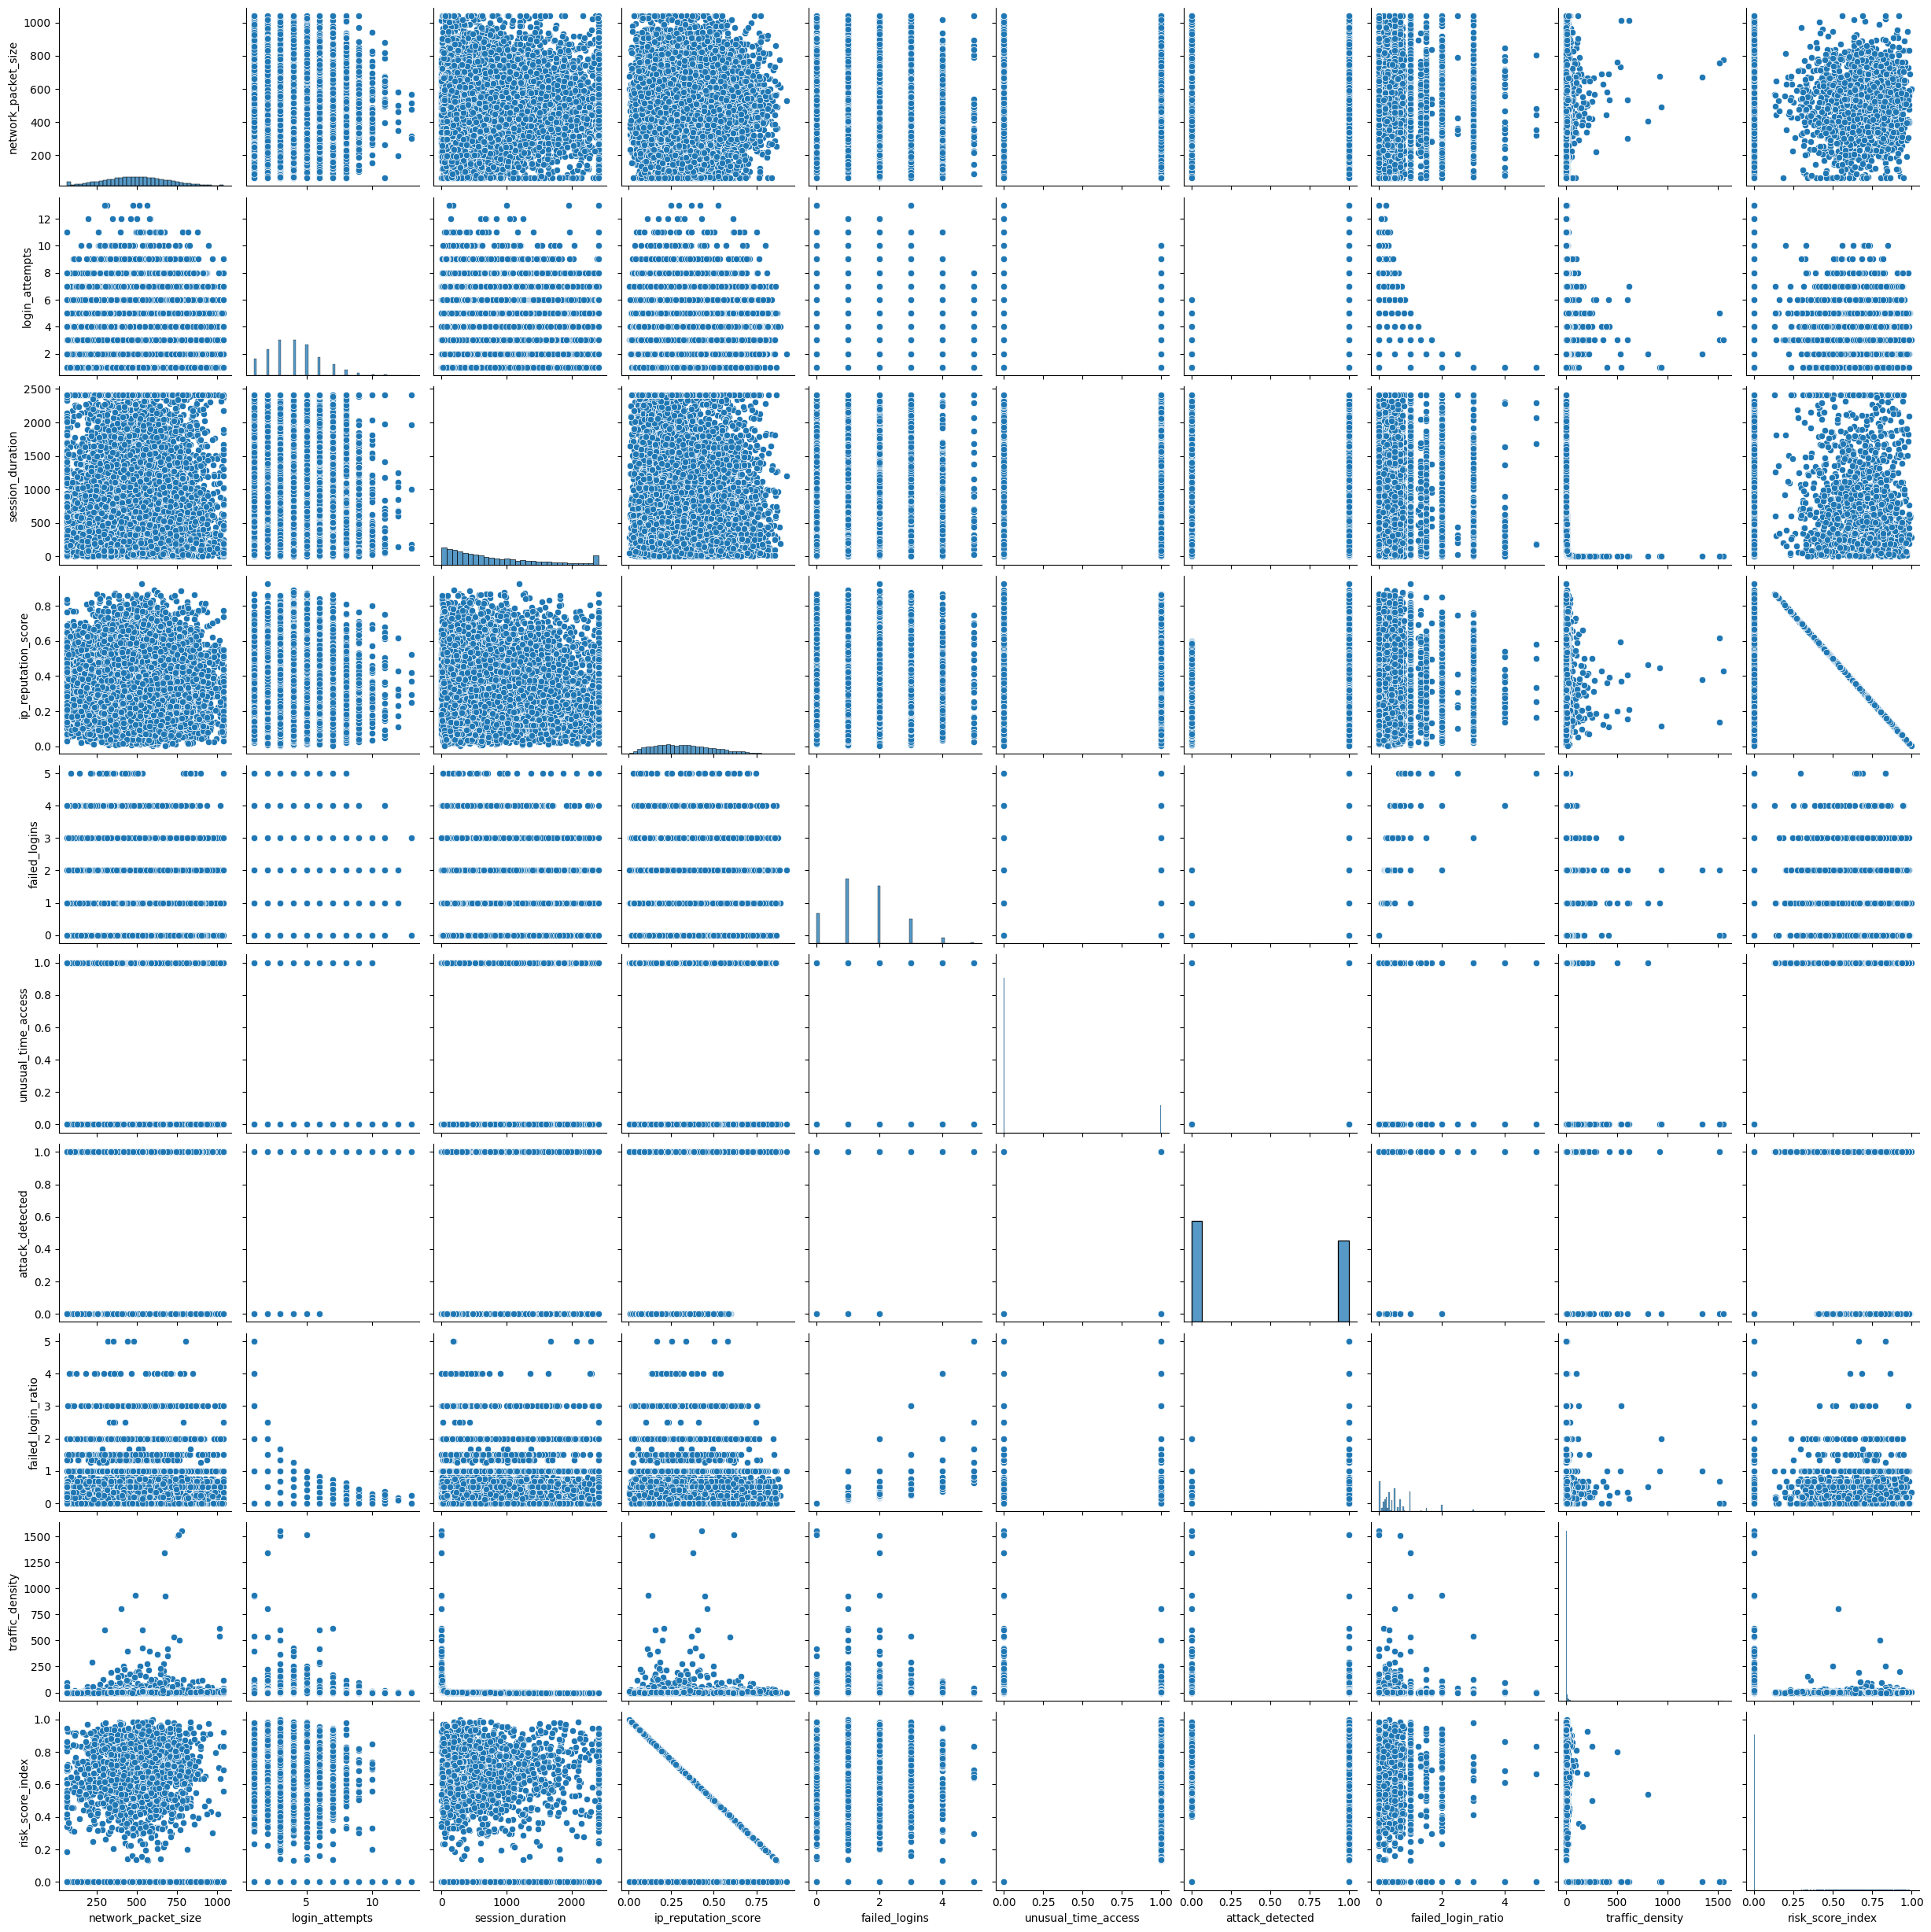

In [40]:
sns.pairplot(df[numeric_columns])



# MODEL TRAINED



In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

In [42]:
le = LabelEncoder()

categorical_columns = [
   'protocol_type',
    'session_id' ,
    'encryption_used', 
    'browser_type'
]

for col in categorical_columns:

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [43]:
print(df.head())

   session_id  network_packet_size  protocol_type  login_attempts  \
0           0                599.0              1               4   
1           1                472.0              1               3   
2           2                629.0              1               3   
3           3                804.0              2               4   
4           4                453.0              1               5   

   session_duration  encryption_used  ip_reputation_score  failed_logins  \
0        492.983263                1             0.606818              1   
1       1557.996461                1             0.301569              0   
2         75.044262                1             0.739164              2   
3        601.248835                1             0.123267              0   
4        532.540888                0             0.054874              1   

   browser_type  unusual_time_access  attack_detected  failed_login_ratio  \
0             1                    0               

In [44]:
X = df.drop(columns=['session_id','attack_detected'])
y = df['attack_detected']

In [45]:
categorical_cols = ['protocol_type' , 'encryption_used', 'browser_type']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough' 
)

In [47]:
X_processed = preprocessor.fit_transform(X)

In [48]:
encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(encoded_cat_features) + numerical_cols

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [51]:
print("Training the XGBoost model...")
xgb_model.fit(X_train, y_train)
print("Model trained successfully!\n")

Training the XGBoost model...
Model trained successfully!



In [52]:
y_pred = xgb_model.predict(X_test)

In [53]:
print("--- Evaluation Metrics ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Evaluation Metrics ---
Accuracy: 0.8847

Confusion Matrix:
[[1053    2]
 [ 218  635]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1055
           1       1.00      0.74      0.85       853

    accuracy                           0.88      1908
   macro avg       0.91      0.87      0.88      1908
weighted avg       0.90      0.88      0.88      1908



In [54]:
new_data = pd.DataFrame([{
    
    'session_id':4,
    'network_packet_size': 710,
    'protocol_type': 0,
    'login_attempts': 6,
    'session_duration': 820.5,
    'encryption_used': 1,
    'ip_reputation_score': 0.85,
    'failed_logins': 2,
    'browser_type': 1,
    'unusual_time_access': 1,
    'traffic_density':3,
   'risk_score_index':4,
   'failed_login_ratio':5
}])

In [55]:
new_data = preprocessor.transform(new_data)

In [56]:
prediction = xgb_model.predict(new_data)
prediction_proba = xgb_model.predict_proba(new_data)

In [57]:

if prediction[0] == 1:
    print(f"⚠️ Alert: Attack Detected! (Confidence: {prediction_proba[0][1]:.2%})")
else:
    print(f"✅ Safe: Normal Traffic. (Confidence: {prediction_proba[0][0]:.2%})")

⚠️ Alert: Attack Detected! (Confidence: 99.91%)


## Saving the trained Model

In [58]:
import joblib

In [59]:
joblib.dump(xgb_model, 'cybersecurity_intrusion.pkl')

['cybersecurity_intrusion.pkl']